# Incident Ops: exploratory KTLO analysis

Exploration of the deterministic sample in `data/sample_incidents.csv` through the same use cases the API serves, plus a pandas view of the domain records. The window ends on 2026-09-28, the last day of the sample.

Re-run with `uv run --group notebook jupyter nbconvert --execute --inplace notebooks/ktlo_exploration.ipynb`.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from incident_insights.application.clock import fixed_clock
from incident_insights.domain.shared.reporting_window import ReportingWindow
from incident_insights.infrastructure.composition import build_use_cases
from incident_insights.infrastructure.incidents.acl import IncidentTranslator
from incident_insights.infrastructure.incidents.csv_source import CsvIncidentSource
from incident_insights.infrastructure.settings import DataSourceKind, Settings

pd.set_option("display.width", 140)
AS_OF = datetime(2026, 9, 28, tzinfo=UTC)
SAMPLE = Path("../data/sample_incidents.csv")
settings = Settings(insights_data_source=DataSourceKind.CSV, insights_csv_path=SAMPLE)
use_cases = build_use_cases(settings, fixed_clock(AS_OF))
history = CsvIncidentSource(SAMPLE, IncidentTranslator()).export(ReportingWindow.trailing(180, AS_OF))
frame = pd.DataFrame(
    [
        {
            "service": str(record.service),
            "severity": record.severity.value,
            "source": record.source.value,
            "mtta_minutes": record.minutes_to_acknowledge(),
            "mttr_minutes": record.minutes_to_resolve(),
            "week_start": record.week_start(),
            "complies": record.complies_with_sla(),
        }
        for record in history
    ]
)
frame.shape

(413, 7)

## Shape of the data

Incidents per service and severity over the window.

In [2]:
pd.crosstab(frame["service"], frame["severity"], margins=True)

severity,Sev1,Sev2,Sev3,Sev4,All
service,,,,,
checkout,12,22,29,13,76
identity,9,41,17,2,69
notifications,3,15,38,7,63
payments-gateway,14,35,33,9,91
platform,3,6,20,1,30
reporting,1,3,14,11,29
search,3,13,29,10,55
All,45,135,180,53,413


## Response times

MTTA and MTTR are right-skewed, so the API reports median and p90 rather than the mean.

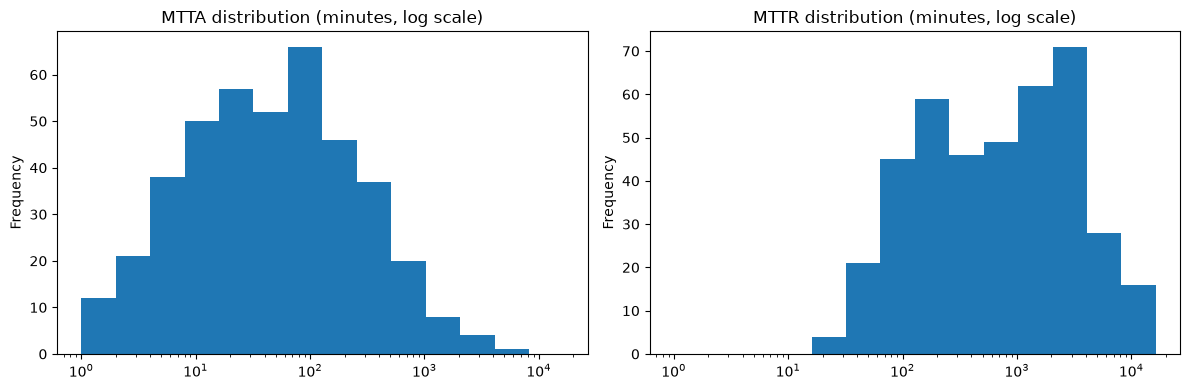

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, column, label in zip(axes, ["mtta_minutes", "mttr_minutes"], ["MTTA", "MTTR"]):
    frame[column].dropna().clip(lower=1).plot.hist(
        ax=axis, bins=[2 ** power for power in range(15)], logx=True
    )
    axis.set_title(f"{label} distribution (minutes, log scale)")
fig.tight_layout()

In [4]:
kpis = use_cases.get_kpis.execute(180)
pd.DataFrame(
    [
        {
            "service": group.service_id,
            "incidents": group.incidents,
            "mtta_median": group.mtta.median_minutes,
            "mtta_p90": group.mtta.p90_minutes,
            "mttr_median": group.mttr.median_minutes,
            "mttr_p90": group.mttr.p90_minutes,
            "sla_pct": group.sla.overall_pct,
        }
        for group in kpis.by_service
    ]
).set_index("service").sort_values("mttr_median", ascending=False)

,incidents,mtta_median,mtta_p90,mttr_median,mttr_p90,sla_pct
service,,,,,,
reporting,29,161.4,854.4,2903.4,7730.0,75.9
notifications,63,76.0,402.8,1324.8,8602.6,72.1
search,55,73.6,627.4,1205.9,4312.4,77.4
checkout,76,38.7,426.3,957.8,5735.0,73.7
platform,30,57.3,175.9,724.7,3298.3,83.3
payments-gateway,91,32.9,286.9,537.6,5511.6,70.3
identity,69,17.4,197.8,330.3,3154.5,68.1


## Detection coverage

Alert-detected incidents are acknowledged faster than manual ones.

In [5]:
pd.DataFrame(
    [
        {"source": item.source, "incidents": item.incidents, "share_pct": item.share_pct,
         "mtta_median": item.mtta.median_minutes, "mtta_p90": item.mtta.p90_minutes}
        for item in kpis.detection.by_source
    ]
).set_index("source")

,incidents,share_pct,mtta_median,mtta_p90
source,,,,
Manual,162,39.2,83.1,658.1
Alertmanager,141,34.1,36.0,233.0
AzureMonitor,110,26.6,32.7,289.2


In [6]:
frame.groupby("source")["complies"].mean().mul(100).round(1).rename("sla_compliance_pct")

source
Alertmanager    81.6
AzureMonitor    75.5
Manual          62.3
Name: sla_compliance_pct, dtype: float64

## Weekly trend

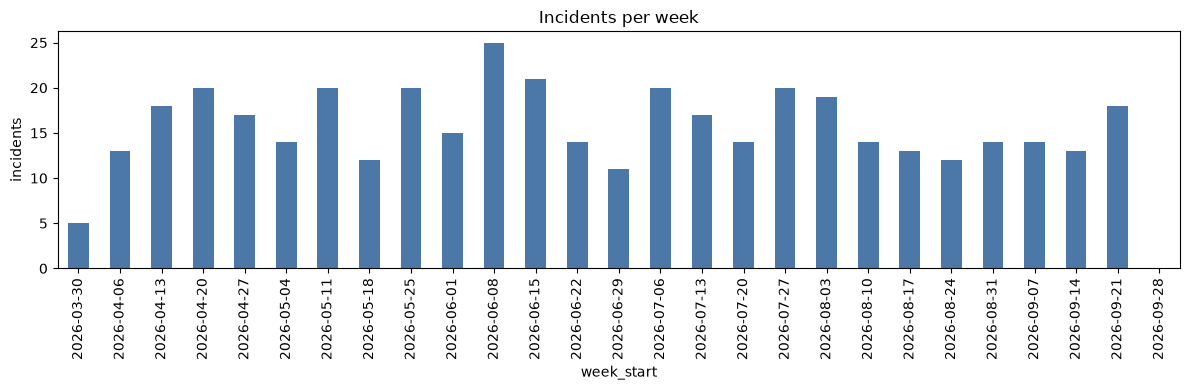

In [7]:
trend = pd.DataFrame([week.model_dump() for week in kpis.weekly]).set_index("week_start")
fig, axis = plt.subplots(figsize=(12, 4))
trend["incidents"].plot.bar(ax=axis, color="#4C78A8")
axis.set_ylabel("incidents")
axis.set_title("Incidents per week")
fig.tight_layout()

## Volume anomalies

Weekly counts per service against a rolling baseline of the previous eight weeks. A week is flagged when its z-score is at least 3 and it has at least 3 incidents.

In [8]:
anomalies = use_cases.detect_anomalies.execute(180)
pd.DataFrame([item.model_dump() for item in anomalies.anomalies])

,service_id,week_start,count,baseline_mean,baseline_std,z_score
0,checkout,2026-05-11,6,2.83,0.90,3.17
1,search,2026-06-08,8,1.50,0.87,6.50
2,checkout,2026-06-15,9,3.12,1.54,3.82
3,payments-gateway,2026-08-03,13,3.75,0.97,9.25
4,reporting,2026-09-07,4,0.75,0.83,3.25


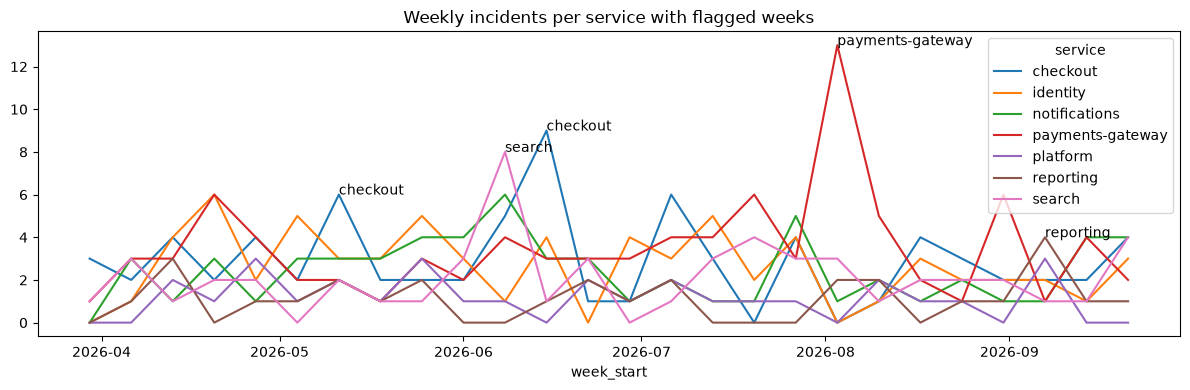

In [9]:
volume = frame.groupby(["week_start", "service"]).size().unstack(fill_value=0)
fig, axis = plt.subplots(figsize=(12, 4))
volume.plot(ax=axis)
for item in anomalies.anomalies:
    axis.annotate(item.service_id, (item.week_start, item.count))
axis.set_title("Weekly incidents per service with flagged weeks")
fig.tight_layout()

## Recurring issues

TF-IDF over title and description, reduced with truncated SVD, clustered with k-means; k is the value with the best cosine silhouette.

In [10]:
recurring = use_cases.find_recurring.execute(180)
print(f"k={recurring.clusters_evaluated}, silhouette={recurring.silhouette}")
pd.DataFrame(
    [
        {"label": cluster.label, "count": cluster.count, "cohesion": cluster.cohesion,
         "services": ", ".join(s.service_id for s in cluster.services)}
        for cluster in recurring.clusters
    ]
)

k=20, silhouette=0.93


,label,count,cohesion,services
0,failures invalid / invalid token / login failures,32,0.963,identity
1,error rate / deployment / rate spike,31,0.861,"payments-gateway, identity, checkout, platform..."
2,connection pool / database connection / exhausted,29,0.931,"notifications, checkout, identity, payments-ga..."
3,acquirer authorization / authorization timeout...,27,1.000,payments-gateway
4,backlog payment / delivery backlog / payment w...,25,1.000,payments-gateway
5,codes delivered / mfa sms / delayed delivered,25,0.962,identity
6,push notifications / android devices / failing...,25,1.000,notifications
7,certificate expiring / automated renewal / day...,24,0.869,"notifications, checkout, payments-gateway, sea..."
8,search / catalog update / index lag,23,1.000,search
9,charges reported / customers customers / dupli...,22,1.000,payments-gateway
